In [1]:
import os
import librosa
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import warnings
warnings.filterwarnings('ignore')

print("Generating Deep CNN Features (Log-Mel Spectrograms)")

# Load segment manifest from preprocessing.ipynb
df = pd.read_csv("../DATA/processed/segment_manifest.csv")

TARGET_SR = 22050
WIN_LEN_MS = 25
HOP_LEN_MS = 10
FMAX = 8000  #  Hybrid Touch: Paper found only first 8kHz is useful

# Convert ms to samples
win_length = int((WIN_LEN_MS / 1000) * TARGET_SR)
hop_length = int((HOP_LEN_MS / 1000) * TARGET_SR)
n_fft = 1024 # Closest power of 2 for 551 (win_length)

X_data = []
y_data = []
class_mapping = {label: idx for idx, label in enumerate(df['class_label'].unique())}

print("Processing chunks to 128x128 images. Please wait")

for idx, row in df.iterrows():
    # Load segment
    y, sr = librosa.load(row['filepath'], sr=TARGET_SR, mono=True)
    
    # 1. Compute Mel Spectrogram
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, win_length=win_length,
        window='hann', n_mels=128, fmax=FMAX
    )
    
    # 2. Log Compression [-80, 0] dB
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    # 3. Resize to 128x128 using PyTorch Bilinear Interpolation
    # Convert S_dB to tensor shape (1, 1, H, W) for interpolation
    tensor_img = torch.tensor(S_dB).unsqueeze(0).unsqueeze(0)
    resized_img = F.interpolate(tensor_img, size=(128, 128), mode='bilinear', align_corners=False)
    
    # Extract back to (1, 128, 128) for CNN input
    final_img = resized_img.squeeze(0).numpy()
    
    X_data.append(final_img)
    y_data.append(class_mapping[row['class_label']])

# Convert to final Tensors
X_tensor = np.array(X_data)  # Shape: (N, 1, 128, 128)
y_tensor = np.array(y_data)

# Save the dataset tensors
os.makedirs("../DATA/tensors", exist_ok=True)
np.save("../DATA/tensors/X_features.npy", X_tensor)
np.save("../DATA/tensors/y_labels.npy", y_tensor)
np.save("../DATA/tensors/class_mapping.npy", class_mapping)

print(f"Tensors saved, Feature Shape: {X_tensor.shape}")

Generating Deep CNN Features (Log-Mel Spectrograms)
Processing chunks to 128x128 images. Please wait
Tensors saved, Feature Shape: (4100, 1, 128, 128)


Generating 5-Panel Visualization


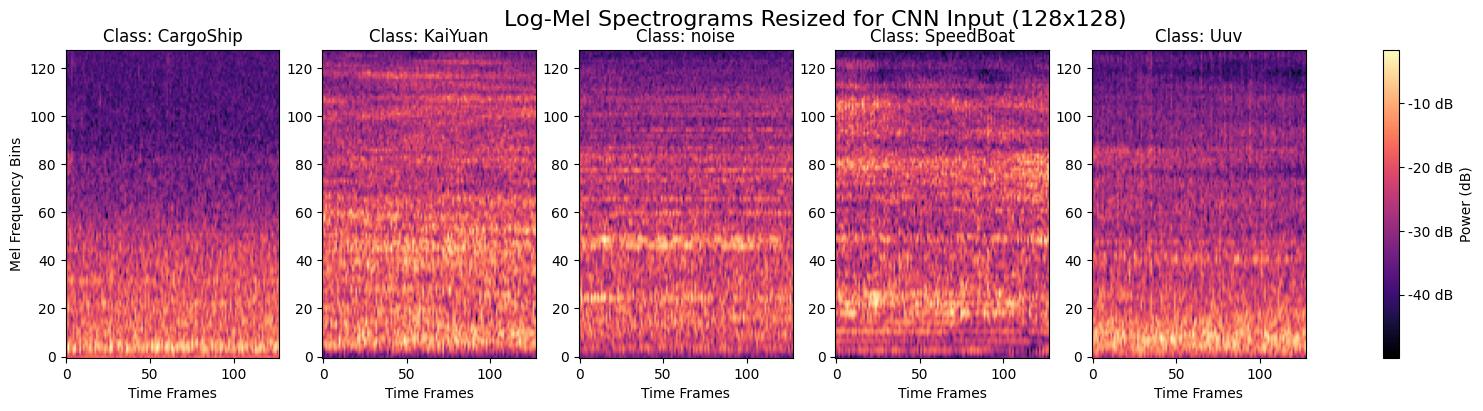

Visualization Done


In [2]:
import matplotlib.pyplot as plt
import librosa.display

print("Generating 5-Panel Visualization")

# Get unique classes
unique_classes = df['class_label'].unique()
fig, axes = plt.subplots(1, len(unique_classes), figsize=(20, 4))

for i, cls in enumerate(unique_classes):
    # Find the first image of this class
    idx = df[df['class_label'] == cls].index[0]
    img = X_tensor[idx].squeeze() # Remove channel dim for plotting
    
    ax = axes[i]
    # Display the 128x128 image
    mesh = ax.imshow(img, aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f"Class: {cls}")
    ax.set_xlabel("Time Frames")
    if i == 0:
        ax.set_ylabel("Mel Frequency Bins")

plt.colorbar(mesh, ax=axes, format="%+2.0f dB", label='Power (dB)')
plt.suptitle('Log-Mel Spectrograms Resized for CNN Input (128x128)', fontsize=16)
plt.show()

print("Visualization Done")

In [6]:
from torch.utils.data import Dataset, DataLoader

print("Building PyTorch Dataset Class")

class QiandaoEar(Dataset):
    def __init__(self, X_npy_path, y_npy_path):
        """
        Loads the preprocessed (N, 1, 128, 128) numpy arrays into memory
        """
        self.X = np.load(X_npy_path)
        self.y = np.load(y_npy_path)
        
        # Convert to PyTorch tensors
        self.X_tensor = torch.from_numpy(self.X).float()
        self.y_tensor = torch.from_numpy(self.y).long()
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        # Returns (spectrogram_tensor, label) pair
        return self.X_tensor[idx], self.y_tensor[idx]

# Verify it works
dataset = QiandaoEar("../DATA/tensors/X_features.npy", "../DATA/tensors/y_labels.npy")
sample_x, sample_y = dataset[0]

print(f"Dataset Class Ready")
print(f"Single Item Shape: {sample_x.shape}, Label: {sample_y}")


Building PyTorch Dataset Class
Dataset Class Ready
Single Item Shape: torch.Size([1, 128, 128]), Label: 0


In [7]:
import numpy as np
import librosa
import pandas as pd
from scipy.signal import welch, hilbert, find_peaks
import warnings
warnings.filterwarnings('ignore')

print("Hand-Crafted Feature Extractor")

def extract_handcrafted_features(y, sr):
    features = []
    
    # 1. MFCCs + Deltas + Delta-Deltas (40 coeffs -> 120 features per frame)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta1 = librosa.feature.delta(mfccs, order=1)
    delta2 = librosa.feature.delta(mfccs, order=2)
    mfcc_combined = np.vstack([mfccs, delta1, delta2])
    # Mean and Std over time -> 120 means + 120 stds = 240 dims
    features.extend(np.mean(mfcc_combined, axis=1))
    features.extend(np.std(mfcc_combined, axis=1))
    
    # 2. Spectral Features
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, roll_percent=0.85)
    flatness = librosa.feature.spectral_flatness(y=y)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_bands=6) # 7 bands output
    
    spectral_combined = np.vstack([centroid, bandwidth, rolloff, flatness, contrast])
    # Mean and Std over time
    features.extend(np.mean(spectral_combined, axis=1))
    features.extend(np.std(spectral_combined, axis=1))
    
    # 3. LOFAR Spectral Lines (Narrowband PSD using Welch's method)
    # Using nperseg=4096 as requested in PDF
    f_lofar, Pxx_lofar = welch(y, sr, nperseg=4096, noverlap=2048)
    peaks, _ = find_peaks(Pxx_lofar)
    # Get top 5 peaks by amplitude
    if len(peaks) > 0:
        top_peaks_idx = peaks[np.argsort(Pxx_lofar[peaks])][-5:][::-1]
        top_freqs = f_lofar[top_peaks_idx]
        top_amps = Pxx_lofar[top_peaks_idx]
    else:
        top_freqs, top_amps = [], []
        
    # Pad to always have 5 peaks (10 features: 5 freqs + 5 amps)
    top_freqs = np.pad(top_freqs, (0, max(0, 5 - len(top_freqs))), mode='constant')
    top_amps = np.pad(top_amps, (0, max(0, 5 - len(top_amps))), mode='constant')
    features.extend(top_freqs[:5])
    features.extend(top_amps[:5])
    
    # 4. DEMON Spectrum Features (Demodulated Envelope PSD)
    envelope = np.abs(hilbert(y))
    # Remove DC bias before PSD
    envelope = envelope - np.mean(envelope)
    f_demon, Pxx_demon = welch(envelope, sr, nperseg=4096, noverlap=2048)
    demon_peaks, _ = find_peaks(Pxx_demon)
    
    if len(demon_peaks) > 0:
        top_demon_idx = demon_peaks[np.argsort(Pxx_demon[demon_peaks])][-5:][::-1]
        top_demon_freqs = f_demon[top_demon_idx]
        top_demon_amps = Pxx_demon[top_demon_idx]
    else:
        top_demon_freqs, top_demon_amps = [], []
        
    top_demon_freqs = np.pad(top_demon_freqs, (0, max(0, 5 - len(top_demon_freqs))), mode='constant')
    top_demon_amps = np.pad(top_demon_amps, (0, max(0, 5 - len(top_demon_amps))), mode='constant')
    features.extend(top_demon_freqs[:5])
    features.extend(top_demon_amps[:5])
    
    return np.array(features)

print("Feature Extractor Function part is complete")

Hand-Crafted Feature Extractor
Feature Extractor Function part is complete


In [8]:
import os

print("Extracting features for all segments, pls be pateint this might will take time")

df_segments = pd.read_csv("../DATA/processed/segment_manifest.csv")
TARGET_SR = 22050

# Dictionaries to hold our data
data_dict = {'train': {'X': [], 'y': []}, 
             'val': {'X': [], 'y': []}, 
             'test': {'X': [], 'y': []}}

# Load class mapping from previous cell to keep labels consistent
class_mapping = np.load("../DATA/tensors/class_mapping.npy", allow_pickle=True).item()

for idx, row in df_segments.iterrows():
    y, sr = librosa.load(row['filepath'], sr=TARGET_SR, mono=True)
    
    # Extract
    feat_vector = extract_handcrafted_features(y, sr)
    
    # Route to correct split
    split = row['split']
    data_dict[split]['X'].append(feat_vector)
    data_dict[split]['y'].append(class_mapping[row['class_label']])

# Convert lists to numpy arrays
X_train_raw = np.array(data_dict['train']['X'])
y_train = np.array(data_dict['train']['y'])

X_val_raw = np.array(data_dict['val']['X'])
y_val = np.array(data_dict['val']['y'])

X_test_raw = np.array(data_dict['test']['X'])
y_test = np.array(data_dict['test']['y'])

print(f"Extraction Complete, Raw Feature Vector Dimension: {X_train_raw.shape[1]}")

Extracting features for all segments, pls be pateint this might will take time
Extraction Complete, Raw Feature Vector Dimension: 282


Showing 40 MFCCs


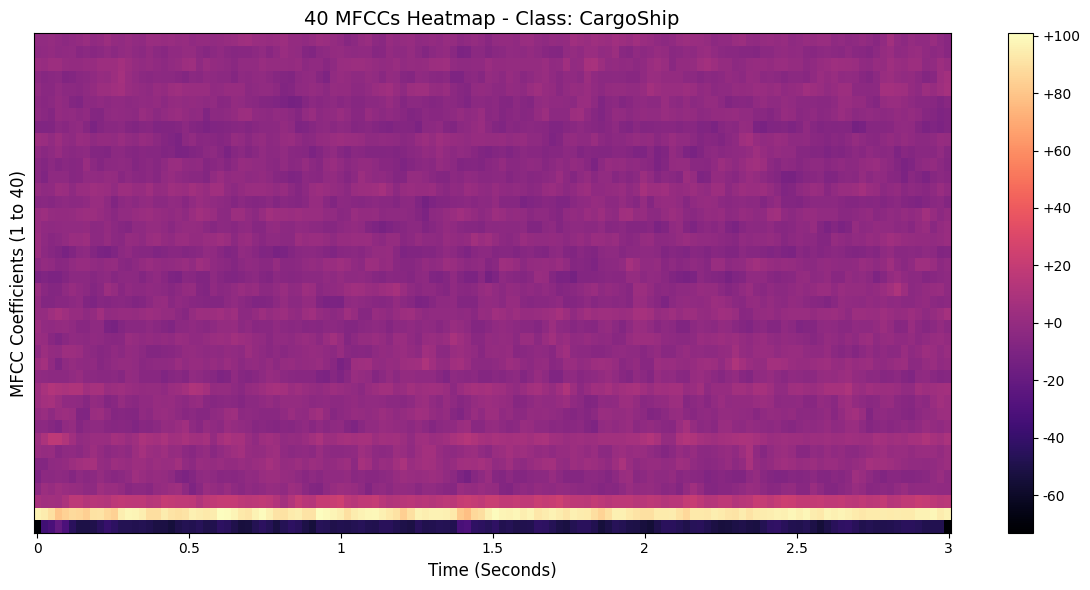

MFCC Shape Matrix: (40, 130) (40 Coefficients x Time Frames)


In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd

print("Showing 40 MFCCs")

# Load our segment manifest to pick one file
df_segments = pd.read_csv("../DATA/processed/segment_manifest.csv")
TARGET_SR = 22050

# Pick the very first file from the dataset for demonstration
sample_filepath = df_segments.iloc[0]['filepath']
sample_class = df_segments.iloc[0]['class_label']

# Load the audio
y, sr = librosa.load(sample_filepath, sr=TARGET_SR, mono=True)

# Compute the 40 MFCCs across time frames
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)

# Draw the Heatmap
plt.figure(figsize=(12, 6))
# Using 'magma' colormap for a professional look, but you can change to 'viridis' or 'coolwarm'
img = librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='magma')

plt.colorbar(img, format="%+2.0f")
plt.title(f'40 MFCCs Heatmap - Class: {sample_class}', fontsize=14)
plt.ylabel('MFCC Coefficients (1 to 40)', fontsize=12)
plt.xlabel('Time (Seconds)', fontsize=12)
plt.tight_layout()
plt.show()

print(f"MFCC Shape Matrix: {mfccs.shape} (40 Coefficients x Time Frames)")

Scaling, Saving features and all till now, and Plotting PCA


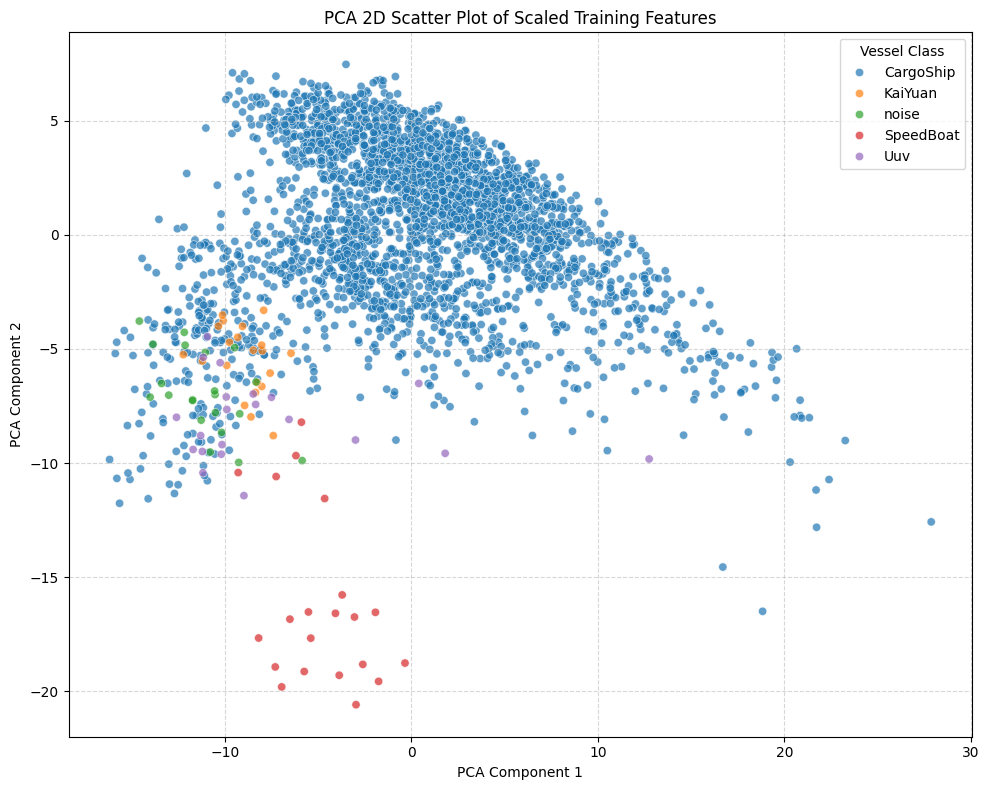


CLASSICAL ML FEATURES (PART 4) IS 100% FULLY DONE
Saved: features_train.npy, features_val.npy, features_test.npy, scaler.pkl


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Scaling, Saving features and all till now, and Plotting PCA")

# 1. Scale Features (Fit ONLY on Train!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

# 2. Save Deliverables
save_dir = "../DATA/classical_ml"
os.makedirs(save_dir, exist_ok=True)

np.save(os.path.join(save_dir, "features_train.npy"), X_train)
np.save(os.path.join(save_dir, "y_train.npy"), y_train) # Saving labels too for ML
np.save(os.path.join(save_dir, "features_val.npy"), X_val)
np.save(os.path.join(save_dir, "y_val.npy"), y_val)
np.save(os.path.join(save_dir, "features_test.npy"), X_test)
np.save(os.path.join(save_dir, "y_test.npy"), y_test)

joblib.dump(scaler, os.path.join(save_dir, "scaler.pkl"))

# 3. PCA 2D Scatter Plot (Deliverable)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

# Prepare DataFrame for Plotting
reverse_mapping = {v: k for k, v in class_mapping.items()}
plot_labels = [reverse_mapping[label] for label in y_train]

pca_df = pd.DataFrame({
    'PCA Component 1': X_train_pca[:, 0],
    'PCA Component 2': X_train_pca[:, 1],
    'Vessel Class': plot_labels
})

plt.figure(figsize=(10, 8))
sns.scatterplot(data=pca_df, x='PCA Component 1', y='PCA Component 2', 
                hue='Vessel Class', palette='tab10', alpha=0.7)
plt.title('PCA 2D Scatter Plot of Scaled Training Features')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nCLASSICAL ML FEATURES (PART 4) IS 100% FULLY DONE")
print("Saved: features_train.npy, features_val.npy, features_test.npy, scaler.pkl")